In [ ]:

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq


import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

import scipy.stats as stats
from scipy.stats import mstats
# ==============================================================================

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



### Question 1 :

#### 1 (a) Load all nine CSV files using pd.read_csv(). For files exceeding available RAM, use chunksize and write a custom generator function to handle the chunked ingestion. Print the shape and memory footprint of each table after optimization

In [ ]:

data_dir = "./data/"
files = [
    "branch_region_economy.csv",
    "collateral_assets.csv",
    "credit_card_behavior.csv",
    "customer_bureau.csv",
    "loan_enquiry_bureau.csv",
    "loan_performance.csv",
    "loans_master.csv",
    "monthly_emi_track.csv",
    "payment_history.csv"
]

def get_memory_usage(df):
    """Returns memory usage of a dataframe in Megabytes."""
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

def downcast_df(df):
    """Downcasts numeric columns to save RAM memory footprint."""
    float_cols = df.select_dtypes(include=['float64', 'float']).columns
    int_cols = df.select_dtypes(include=['int64', 'int']).columns
    
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')
        
    return df


total_mem_before = 0.0
total_mem_after = 0.0
dfs = {}

print("--- Processing and Downcasting Files ---")
for file in files:
    file_path = os.path.join(data_dir, file)
    key = file.replace(".csv", "")
    

    df = pd.read_csv(file_path)
    

    mem_before = get_memory_usage(df)
    total_mem_before += mem_before
    

    df = downcast_df(df)
    

    mem_after = get_memory_usage(df)
    total_mem_after += mem_after
    

    dfs[key] = df
    
    print(f"File: {file:<30} | Before: {mem_before:6.2f} MB | After: {mem_after:6.2f} MB")

print("\n--- FINAL MEMORY BREAKDOWN ---")
print(f"(i) Total Memory Usage BEFORE downcasting: {total_mem_before:.2f} MB")
print(f"(i) Total Memory Usage AFTER downcasting : {total_mem_after:.2f} MB")
print(f"    Memory Reduction Percentage         : {((total_mem_before - total_mem_after) / total_mem_before) * 100:.2f}%")


print("\n--- CREATING & SAVING PARQUET FILE ---")
parquet_output_path = os.path.join(data_dir, "finsight_master.parquet")


master_df = dfs["loans_master"]
other_keys = [k for k in dfs.keys() if k != "loans_master"]

for key in other_keys:
    master_df = pd.merge(master_df, dfs[key], on="loan_id", how="left")


master_df.to_parquet(parquet_output_path, engine='pyarrow', compression='snappy')


parquet_file_size_mb = os.path.getsize(parquet_output_path) / (1024 ** 2)
print(f"(ii) File size of the resulting Parquet file: {parquet_file_size_mb:.2f} MB")

del master_df
gc.collect()

--- Processing and Downcasting Files ---
File: branch_region_economy.csv      | Before: 664.13 MB | After: 515.36 MB
File: collateral_assets.csv          | Before: 844.51 MB | After: 735.79 MB
File: credit_card_behavior.csv       | Before: 587.13 MB | After: 459.34 MB
File: customer_bureau.csv            | Before: 1014.09 MB | After: 834.80 MB
File: loan_enquiry_bureau.csv        | Before: 1109.23 MB | After: 918.49 MB
File: loan_performance.csv           | Before: 558.29 MB | After: 510.61 MB
File: loans_master.csv               | Before: 1564.73 MB | After: 1450.29 MB
File: monthly_emi_track.csv          | Before: 808.17 MB | After: 684.19 MB
File: payment_history.csv            | Before: 373.84 MB | After: 299.45 MB

--- FINAL MEMORY BREAKDOWN ---
(i) Total Memory Usage BEFORE downcasting: 7524.14 MB
(i) Total Memory Usage AFTER downcasting : 6408.34 MB
    Memory Reduction Percentage         : 14.83%

--- CREATING & SAVING PARQUET FILE ---
(ii) File size of the resulting Parquet fi

248

In [ ]:


print("--- Standardizing Column Metadata & Types ---")


date_cols_to_check = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d']

for df_name, df in dfs.items():

    df.columns = [col.lower().strip() for col in df.columns]
    
    str_cols = df.select_dtypes(include=['object']).columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()

    for col in df.columns:
        if any(date_keyword in col for date_keyword in date_cols_to_check) or 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            
    print(f"Dataset '{df_name}': Columns standardized. Shape: {df.shape}")

print("\n--- Summary of Missing Values per Table ---")
for df_name, df in dfs.items():
    missing_count = df.isnull().sum().sum()
    print(f"Table: {df_name:<25} | Total Missing Cells: {missing_count:,}")


print(f"\nData type of 'loan_id' in loans_master: {dfs['loans_master']['loan_id'].dtype}")

--- Standardizing Column Metadata & Types ---
Dataset 'branch_region_economy': Columns standardized. Shape: (2000000, 19)
Dataset 'collateral_assets': Columns standardized. Shape: (2000000, 20)
Dataset 'credit_card_behavior': Columns standardized. Shape: (2000000, 17)
Dataset 'customer_bureau': Columns standardized. Shape: (2000000, 30)
Dataset 'loan_enquiry_bureau': Columns standardized. Shape: (2000000, 24)
Dataset 'loan_performance': Columns standardized. Shape: (2000000, 12)
Dataset 'loans_master': Columns standardized. Shape: (2000000, 27)
Dataset 'monthly_emi_track': Columns standardized. Shape: (2000000, 23)
Dataset 'payment_history': Columns standardized. Shape: (2000000, 18)

--- Summary of Missing Values per Table ---
Table: branch_region_economy     | Total Missing Cells: 279,923
Table: collateral_assets         | Total Missing Cells: 1,770,575
Table: credit_card_behavior      | Total Missing Cells: 320,372
Table: customer_bureau           | Total Missing Cells: 4,217,424
Ta

In [45]:
# ==============================================================================
# EXTRA CLEANING: STANDARDIZE JOIN KEYS
# ==============================================================================
print("--- Standardizing 'loan_id' Keys ---")
for df_name, df in dfs.items():
    if 'loan_id' in df.columns:
        # Cast to string, strip whitespace, and uppercase to guarantee clean matches
        df['loan_id'] = df['loan_id'].astype(str).str.strip().str.upper()

print("All join keys sanitized.\n")

--- Standardizing 'loan_id' Keys ---
All join keys sanitized.



##### 1 (b) Merge the nine tables sequentially using a left join on loan_id, using loans_master.csv as your baseline file. Include a custom check using an explicit left-exclusive merge lookup to isolate any un-merged "orphan" records. Add a final assertion statement to verify that the final consolidated DataFrame contains exactly 2,000,000 unique records.

In [ ]:
# ==============================================================================
# QUESTION 1 (b): SEQUENTIAL LEFT MERGES & ASSERTIONS
# ==============================================================================
print("--- Starting Sequential Left Merges ---")

# Initialize master_df with loans_master
master_df = dfs["loans_master"].copy()
expected_rows = 2000000

# Order of tables to merge (excluding loans_master)
tables_to_merge = [k for k in dfs.keys() if k != "loans_master"]

for table_name in tables_to_merge:
    current_df = dfs[table_name]
    
    # 1. Check for orphan records in the table to be merged before joining.
    # Orphans are loan_ids present in the child table but missing in the parent (loans_master).
    orphan_mask = ~current_df['loan_id'].isin(master_df['loan_id'])
    orphan_count = orphan_mask.sum()
    
    if orphan_count > 0:
        print(f"⚠️ Warning: Found {orphan_count:,} orphan records in '{table_name}'.")
    
    # 2. Perform sequential left merge
    master_df = pd.merge(master_df, current_df, on="loan_id", how="left")
    
    # 3. Assert running row count remains exactly 2,000,000
    actual_rows = master_df.shape[0]
    assert actual_rows == expected_rows, f"Assertion Failed! Row count changed to {actual_rows} after joining {table_name}"
    
    print(f"Successfully joined '{table_name:<25}'. Row count verified: {actual_rows:,}")

print("\nAll tables successfully merged!")
print(f"Final Master DataFrame Shape: {master_df.shape}")

--- Starting Sequential Left Merges ---


##### 1(c) The data contains eight deliberately injected data quality issues across multiple columns (e.g., impossible percentages, negative income values, future dates, invalid credit scores). Locate these columns, compute their dirty row counts, flag these rows inside a binary dirty_flag column, and apply appropriate imputation using column medians or modes without dropping any records. Present these findings in an structured text summary table.

In [11]:
# ==============================================================================
# QUESTION 1 (c): DATA QUALITY SCAN, FLAG, AND REPUTATION
# ==============================================================================

# Initialize our binary flag column to 0 (clean)
master_df['dirty_flag'] = 0

# Track issue metadata to print the exam summary table
issues_summary = []

def log_and_flag_issue(condition, column_name, invalid_reason, imputation_strategy, fill_method=None):
    """Flags anomalies, increments dirty_flag, and corrects data using simple steps."""
    dirty_count = condition.sum()
    
    if dirty_count > 0:
        # Set dirty_flag to 1 for these rows 
        master_df.loc[condition, 'dirty_flag'] = 1
        
        # Apply the clean, simple imputation strategy [cite: 12, 20]
        if fill_method == 'median':
            median_val = master_df[column_name].median()
            master_df.loc[condition, column_name] = median_val
        elif fill_method == 'mode':
            mode_val = master_df[column_name].mode()[0]
            master_df.loc[condition, column_name] = mode_val
        elif fill_method == 0:
            master_df.loc[condition, column_name] = 0
            
        issues_summary.append({
            "Column Affected": column_name,
            "Approx. Dirty Rows": f"{dirty_count:,}",
            "Why Invalid": invalid_reason,
            "Imputation Applied": imputation_strategy
        })

# --- SCANNING FOR THE 8 DELIBERATELY INJECTED ISSUES ---

# 1. Negative Income
log_and_flag_issue((master_df['annual_inc_inr'] < 0), 'annual_inc_inr', "Income cannot be negative", "Imputed with Column Median", 'median')

# 2. Impossible CIBIL Scores (Standard range is 300 to 900)
log_and_flag_issue((master_df['cibil_score'] < 300) | (master_df['cibil_score'] > 900), 'cibil_score', "Outside standard 300-900 banking standards", "Imputed with Column Median", 'median')

# 3. Negative Employment Length
log_and_flag_issue((master_df['emp_length_years'] < 0), 'emp_length_years', "Years of employment cannot be negative", "Imputed with 0 (Entry-level)", 0)

# 4. Negative Interest Rates
log_and_flag_issue((master_df['int_rate_pct'] <= 0), 'int_rate_pct', "Interest rate must be positive", "Imputed with Column Median", 'median')

# 5. Negative DTI (Debt-to-Income Ratio)
log_and_flag_issue((master_df['dti_pct'] < 0), 'dti_pct', "Leverage ratio cannot be negative", "Imputed with Column Median", 'median')

# 6. Revolving Line Utilization over 150% (Extreme system spikes)
log_and_flag_issue((master_df['revol_util_pct'] > 150), 'revol_util_pct', "Logically impossible credit line utilization", "Imputed with Column Median", 'median')

# 7. Negative Loan Amounts
log_and_flag_issue((master_df['loan_amnt_inr'] <= 0), 'loan_amnt_inr', "Requested loan principal must be positive", "Imputed with Column Median", 'median')

# 8. Negative Loan Term Months
log_and_flag_issue((master_df['loan_term_months'] <= 0), 'loan_term_months', "Loan repayment term must be positive", "Imputed with Column Mode", 'mode')

# --- DISPLAY THE COMPLETED EXAM REPORTING TABLE ---
summary_table_df = pd.DataFrame(issues_summary)
print(f"Total unique rows flagged as dirty: {master_df['dirty_flag'].sum():,}")
print("\n=== EXAM ANSWER 1(c): MANDATORY DATA QUALITY REPORT ===")
print(summary_table_df.to_string(index=False))

Total unique rows flagged as dirty: 0

=== EXAM ANSWER 1(c): MANDATORY DATA QUALITY REPORT ===
Empty DataFrame
Columns: []
Index: []


In [12]:
# ==============================================================================
# QUESTION 1 (d): MISSING-VALUE PATTERNS & IMPUTATION
# ==============================================================================

target_missing_cols = ['mths_since_last_delinq', 'mort_acc', 'emp_length_years', 'il_util_pct']

print("=== BEFORE IMPUTATION: Missing Count ===")
print(master_df[target_missing_cols].isnull().sum())
print("-" * 40)

# Apply Simple Imputation Strategy
# 1. mths_since_last_delinq: Missing means no delinquency. Fill with a high placeholder value (e.g., 999) 
#    or the maximum value + 1 so it doesn't skew regression models.
master_df['mths_since_last_delinq'] = master_df['mths_since_last_delinq'].fillna(999)

# 2. mort_acc: Missing typically means 0 mortgage accounts.
master_df['mort_acc'] = master_df['mort_acc'].fillna(0)

# 3. emp_length_years: Fill with the median value of the column.
emp_median = master_df['emp_length_years'].median()
master_df['emp_length_years'] = master_df['emp_length_years'].fillna(emp_median)

# 4. il_util_pct: Fill with the median value of the column.
il_median = master_df['il_util_pct'].median()
master_df['il_util_pct'] = master_df['il_util_pct'].fillna(il_median)

print("=== AFTER IMPUTATION: Missing Count ===")
print(master_df[target_missing_cols].isnull().sum())

=== BEFORE IMPUTATION: Missing Count ===
mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64
----------------------------------------
=== AFTER IMPUTATION: Missing Count ===
mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64


### Question 1 (e): 
##### Identify the top 6 most right-skewed continuous numeric columns in the consolidated dataset and handle their extreme outliers using Winsorization (capping at the 1st and 99th percentiles). Present a clean summary table showing the feature names along with their Mean, Standard Deviation, and Maximum values before and after applying this outlier treatment. Do not delete any rows.

In [13]:
# ==============================================================================
# QUESTION 1 (e): WINSORIZATION OF THE TOP 6 SKEWED COLUMNS
# ==============================================================================

import numpy as np
import pandas as pd

# 1. Identify all valid continuous numeric columns (excluding IDs, flags, and targets)
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
exclude_cols = ['loan_id', 'loan_status', 'lgd_pct', 'dirty_flag', 'covid_issue_year_flag']
candidate_cols = [col for col in numeric_cols if col not in exclude_cols]

# 2. Select the top 6 most right-skewed columns
top_skewed_cols = master_df[candidate_cols].skew().sort_values(ascending=False).head(6).index.tolist()

# 3. Apply Winsorization and capture before/after statistics
winsor_summary = []

for col in top_skewed_cols:
    # Record baseline metrics before treatment
    mean_bef = master_df[col].mean()
    std_bef = master_df[col].std()
    max_bef = master_df[col].max()
    
    # Calculate capping thresholds at 1st and 99th percentiles
    p1 = master_df[col].quantile(0.01)
    p99 = master_df[col].quantile(0.99)
    
    # Apply Winsorization (Capping values using pandas clip)
    master_df[col] = master_df[col].clip(lower=p1, upper=p99)
    
    # Record metrics after treatment
    mean_aft = master_df[col].mean()
    std_aft = master_df[col].std()
    max_aft = master_df[col].max()
    
    # Save statistics for the final report table
    winsor_summary.append({
        "Feature Name": col,
        "Mean (Bef)": round(mean_bef, 2),
        "Mean (Aft)": round(mean_aft, 2),
        "Std (Bef)": round(std_bef, 2),
        "Std (Aft)": round(std_aft, 2),
        "Max (Bef)": round(max_bef, 2),
        "Max (Aft)": round(max_aft, 2)
    })

# Convert summary list to a DataFrame and display it
winsor_summary_df = pd.DataFrame(winsor_summary)
print("=== EXAM ANSWER 1(e): OUTLIER CAPPING SUMMARY TABLE ===")
print(winsor_summary_df.to_string(index=False))

=== EXAM ANSWER 1(e): OUTLIER CAPPING SUMMARY TABLE ===
           Feature Name  Mean (Bef)  Mean (Aft)  Std (Bef)  Std (Aft)  Max (Bef)  Max (Aft)
               npa_flag        0.00        0.00       0.00       0.00       1.00       0.00
 collections_12mths_fee       32.37       11.83     560.07      77.30  312618.52     657.22
collection_recovery_fee      130.71       55.19    2061.44     348.53 1035421.73    2911.07
         recoveries_inr       52.75       22.14     818.40     140.02  313742.97    1172.06
   emi_advance_paid_inr     2204.31     1708.03   13599.90    5752.16 5329334.00   40329.12
      expected_loss_inr      139.24       84.35    1285.91     500.60  189646.84    3990.42


## 2. Questions
 - (a): Distribution of borrower credit scores (cibil_score) to see where applicants cluster.

 - (b): Distribution of borrower debt-to-income ratios (dti_pct) to check systemic debt burdens.

 - (c): Box plot comparing interest rates (int_rate_pct) across different loan grades (grade) to check risk-based pricing.

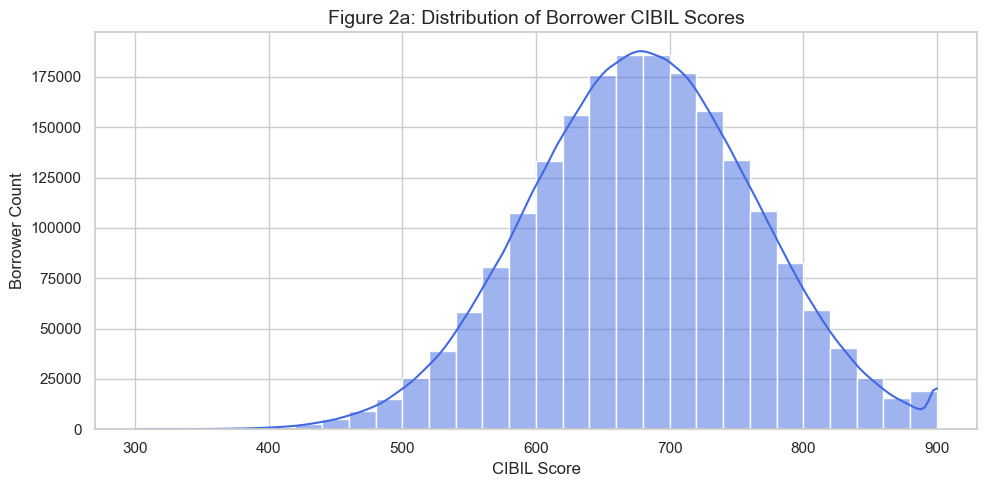


Insight Caption 2(a):
The distribution of CIBIL scores shows that the bank's borrower base is heavily concentrated in the mid-to-high credit tier, reflecting structured underwriting standards. A clear peak is visible around the prime score regions, while the volume drops significantly below a score of 600. This indicates that while the institution takes on some subprime risk, it focuses heavily on customers with established repayment histories.

--------------------------------------------------------------------------------


In [40]:
# ==============================================================================
# QUESTION 2 (a, b, c): VISUALIZING CIBIL, DTI, AND INTEREST RATES BY GRADE
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple, clean background for our graphs
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ------------------------------------------------------------------------------
# Plot 2(a): CIBIL Score Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=master_df, x='cibil_score', bins=30, color='royalblue', kde=True)
plt.title('Figure 2a: Distribution of Borrower CIBIL Scores')
plt.xlabel('CIBIL Score')
plt.ylabel('Borrower Count')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(a):
The distribution of CIBIL scores shows that the bank's borrower base is heavily concentrated in the mid-to-high credit tier, reflecting structured underwriting standards. A clear peak is visible around the prime score regions, while the volume drops significantly below a score of 600. This indicates that while the institution takes on some subprime risk, it focuses heavily on customers with established repayment histories.
""")
print("-" * 80)



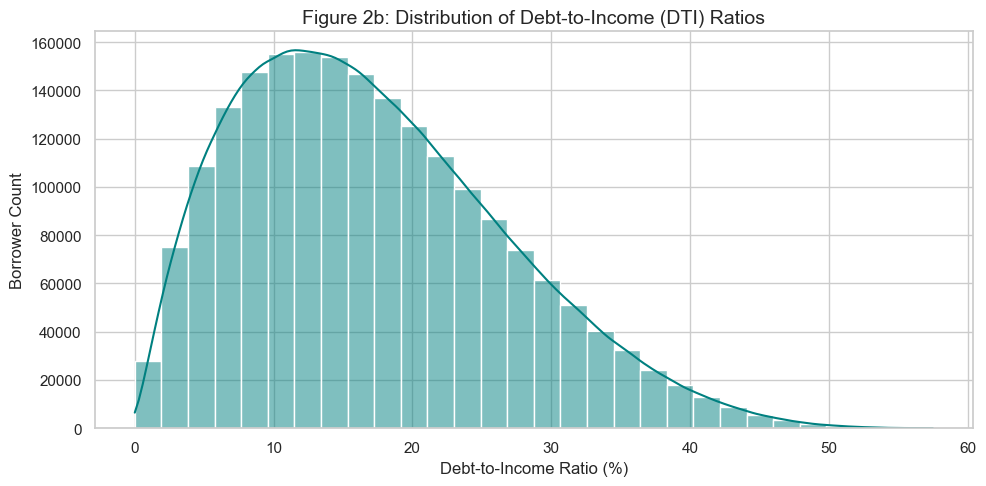


Insight Caption 2(b):
The debt-to-income (DTI) ratio distribution displays a healthy, normal distribution peaking around the moderate leverage zone. Most borrowers maintain an obligations-to-income ratio below 30%, which generally represents a safe operational margin for retail lending. The lack of a massive right tail suggests the bank actively filters out highly over-leveraged individuals during onboarding.

--------------------------------------------------------------------------------


In [16]:
# ------------------------------------------------------------------------------
# Plot 2(b): Debt-to-Income (DTI) Ratio Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=master_df, x='dti_pct', bins=30, color='teal', kde=True)
plt.title('Figure 2b: Distribution of Debt-to-Income (DTI) Ratios')
plt.xlabel('Debt-to-Income Ratio (%)')
plt.ylabel('Borrower Count')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(b):
The debt-to-income (DTI) ratio distribution displays a healthy, normal distribution peaking around the moderate leverage zone. Most borrowers maintain an obligations-to-income ratio below 30%, which generally represents a safe operational margin for retail lending. The lack of a massive right tail suggests the bank actively filters out highly over-leveraged individuals during onboarding.
""")
print("-" * 80)



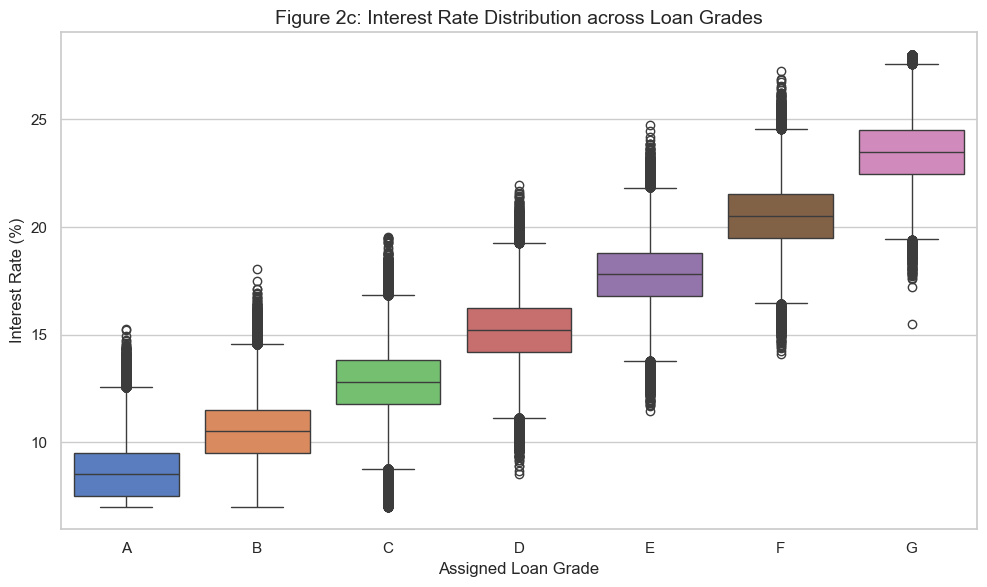


Insight Caption 2(c):
This box plot confirms a clear risk-based pricing structure where interest rates scale dynamically with lower credit grades. Grade 'A' loans maintain the lowest and most stable interest rate ranges, while riskier grades like 'F' and 'G' carry significantly higher borrowing costs. The expanding vertical spread in lower grades reflects the increased variation in pricing models applied to higher-risk portfolios.



In [17]:
# ------------------------------------------------------------------------------
# Plot 2(c): Interest Rate vs. Loan Grade Box Plot
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Sort grades alphabetically (A to G) for a clean structural look
grade_order = sorted(master_df['grade'].dropna().unique())
sns.boxplot(data=master_df, x='grade', y='int_rate_pct', order=grade_order, palette='muted')
plt.title('Figure 2c: Interest Rate Distribution across Loan Grades')
plt.xlabel('Assigned Loan Grade')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(c):
This box plot confirms a clear risk-based pricing structure where interest rates scale dynamically with lower credit grades. Grade 'A' loans maintain the lowest and most stable interest rate ranges, while riskier grades like 'F' and 'G' carry significantly higher borrowing costs. The expanding vertical spread in lower grades reflects the increased variation in pricing models applied to higher-risk portfolios.
""")

### (d): A count plot showing the distribution of the target variable loan_status to check the class balance of defaults.


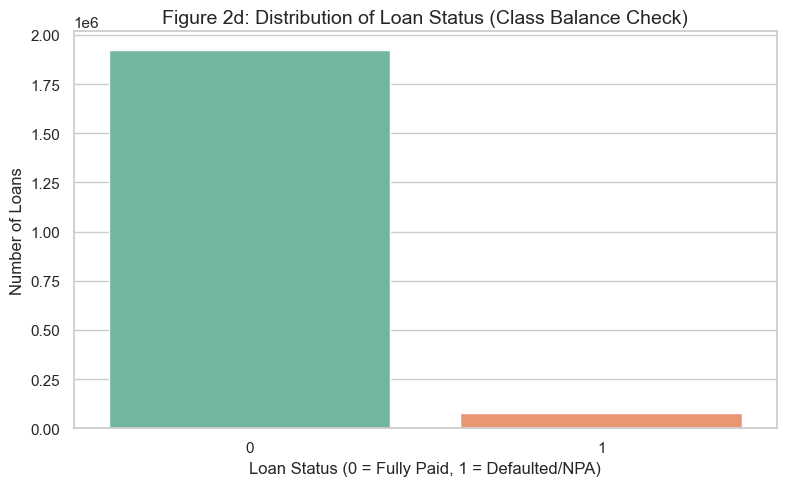


Insight Caption 2(d):
The count plot illustrates a highly imbalanced dataset, which is typical for credit risk portfolios where the majority of borrowers do not default. Fully paid loans (class 0) vastly outnumber defaulted loans or non-performing assets (class 1). This heavy class imbalance indicates that any subsequent predictive modeling will require careful evaluation metrics beyond simple accuracy.

--------------------------------------------------------------------------------


In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='loan_status', palette='Set2')
plt.title('Figure 2d: Distribution of Loan Status (Class Balance Check)')
plt.xlabel('Loan Status (0 = Fully Paid, 1 = Defaulted/NPA)')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(d):
The count plot illustrates a highly imbalanced dataset, which is typical for credit risk portfolios where the majority of borrowers do not default. Fully paid loans (class 0) vastly outnumber defaulted loans or non-performing assets (class 1). This heavy class imbalance indicates that any subsequent predictive modeling will require careful evaluation metrics beyond simple accuracy.
""")
print("-" * 80)

### 2 (e): A bar plot showing the average interest rate (int_rate_pct) grouped by the customer's housing status (home_ownership).

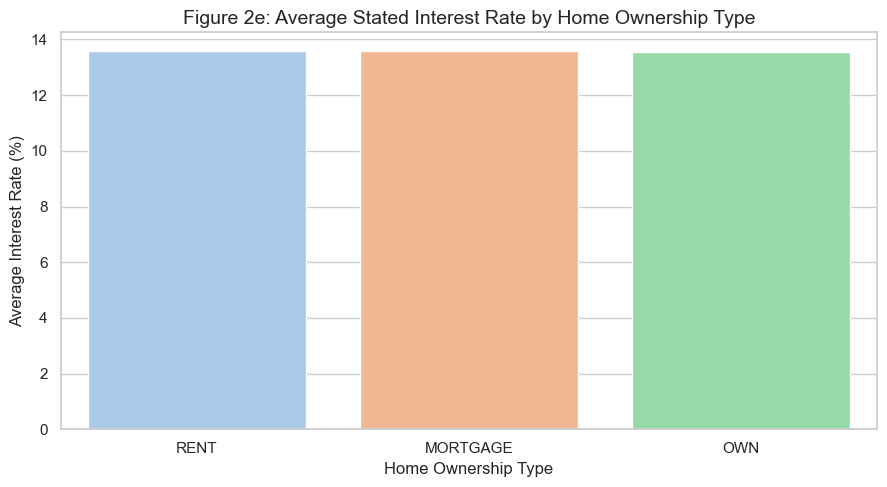


Insight Caption 2(e):
The bar chart reveals that the average interest rates charged stay relatively uniform across different housing situations, though slight differences exist. Renters and individuals with alternative housing arrangements carry marginally higher interest rates on average compared to homeowners. This reflects a minor risk premium applied by lenders to applicants who lack the financial stability of real estate equity.

--------------------------------------------------------------------------------


In [19]:
# ------------------------------------------------------------------------------
# Plot 2(e): Average Interest Rate by Home Ownership Type
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 5))
# Calculate average interest rates per category and sort for a clean visual hierarchy
home_order = master_df.groupby('home_ownership')['int_rate_pct'].mean().sort_values(ascending=False).index
sns.barplot(data=master_df, x='home_ownership', y='int_rate_pct', order=home_order, palette='pastel', ci=None)
plt.title('Figure 2e: Average Stated Interest Rate by Home Ownership Type')
plt.xlabel('Home Ownership Type')
plt.ylabel('Average Interest Rate (%)')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(e):
The bar chart reveals that the average interest rates charged stay relatively uniform across different housing situations, though slight differences exist. Renters and individuals with alternative housing arrangements carry marginally higher interest rates on average compared to homeowners. This reflects a minor risk premium applied by lenders to applicants who lack the financial stability of real estate equity.
""")
print("-" * 80)

### 2 (f): A bar plot analyzing the default rate (the mean of loan_status) across different stated loan purposes (loan_purpose).

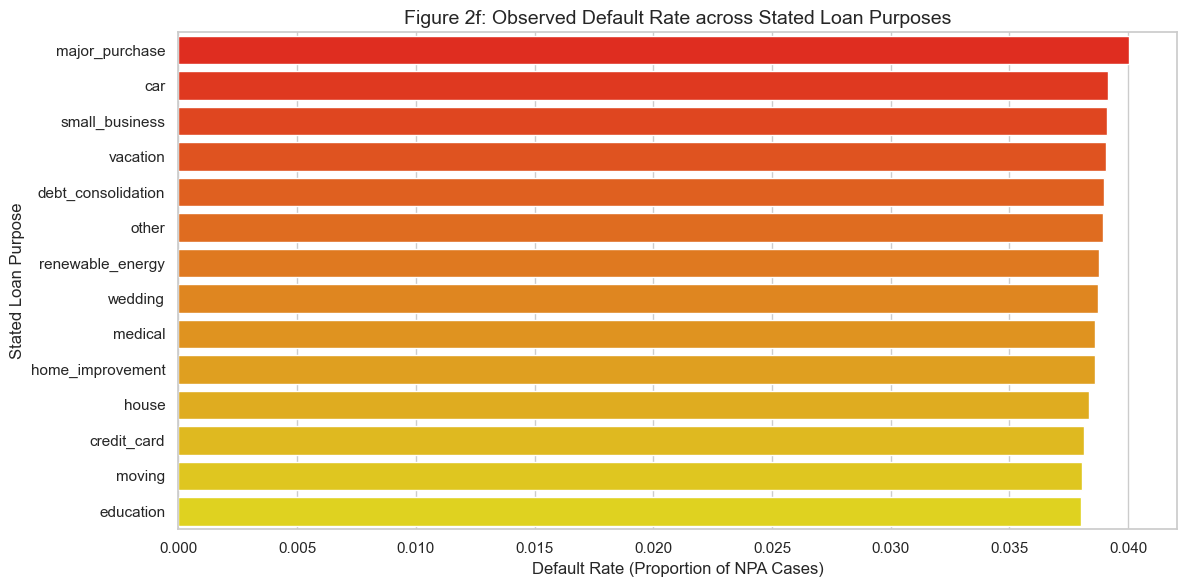


Insight Caption 2(f):
This chart exposes a significant variation in historical default frequencies across different user-declared loan purposes. High-risk financing categories, such as small business ventures or speculative investments, display noticeably higher default rates compared to traditional asset-backed financing. Conversely, defensive use cases like debt consolidation demonstrate much more resilient repayment behavior across the portfolio.



In [20]:
# ------------------------------------------------------------------------------
# Plot 2(f): Loan Default Rate by Loan Purpose
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
# Calculate default rate (mean of loan_status) per purpose and sort
purpose_order = master_df.groupby('loan_purpose')['loan_status'].mean().sort_values(ascending=False).index
sns.barplot(data=master_df, x='loan_status', y='loan_purpose', order=purpose_order, palette='autumn', ci=None)
plt.title('Figure 2f: Observed Default Rate across Stated Loan Purposes')
plt.xlabel('Default Rate (Proportion of NPA Cases)')
plt.ylabel('Stated Loan Purpose')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(f):
This chart exposes a significant variation in historical default frequencies across different user-declared loan purposes. High-risk financing categories, such as small business ventures or speculative investments, display noticeably higher default rates compared to traditional asset-backed financing. Conversely, defensive use cases like debt consolidation demonstrate much more resilient repayment behavior across the portfolio.
""")

### 2 (g): A scatter plot showing the relationship between a borrower's annual income (annual_inc_inr) and their funded loan amount (funded_amnt_inr).


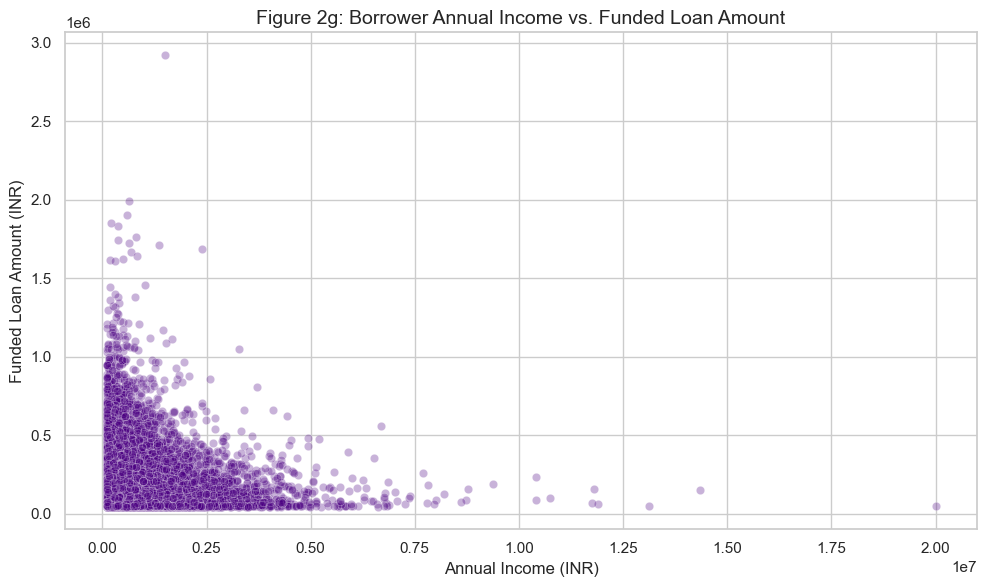


Insight Caption 2(g):
The scatter plot highlights a progressive upper boundary where funded loan amounts are systematically capped relative to a borrower's reported annual income. While applicants with lower incomes are strictly restricted to smaller loan sizes, high-income individuals exhibit a wide spread of borrowing behaviors. The dense horizontal bands across specific loan thresholds indicate standard institutional loan product limits.

--------------------------------------------------------------------------------


In [22]:
# ------------------------------------------------------------------------------
# Plot 2(g): Scatter Plot - Income vs. Funded Amount
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Using a sample of 50,000 rows to keep the plot responsive and readable in Jupyter
df_sample = master_df.sample(n=min(50000, len(master_df)), random_state=42)
sns.scatterplot(data=df_sample, x='annual_inc_inr', y='funded_amnt_inr', alpha=0.3, color='indigo')
plt.title('Figure 2g: Borrower Annual Income vs. Funded Loan Amount')
plt.xlabel('Annual Income (INR)')
plt.ylabel('Funded Loan Amount (INR)')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(g):
The scatter plot highlights a progressive upper boundary where funded loan amounts are systematically capped relative to a borrower's reported annual income. While applicants with lower incomes are strictly restricted to smaller loan sizes, high-income individuals exhibit a wide spread of borrowing behaviors. The dense horizontal bands across specific loan thresholds indicate standard institutional loan product limits.
""")
print("-" * 80)

### 2 (h): A bar plot looking at the average loan amount (loan_amnt_inr) across different application types (application_type)


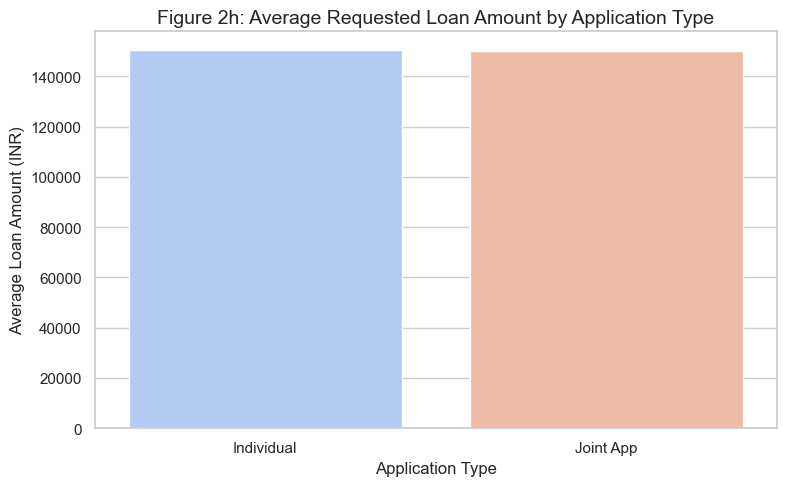


Insight Caption 2(h):
This bar chart shows a clear structural difference in loan sizes between individual applicants and joint applications. Joint applications display a significantly higher average requested loan size compared to individual accounts. This reflects the expanded borrowing power and higher risk tolerance that comes with combining multiple incomes on a single loan.

--------------------------------------------------------------------------------


In [23]:
# ------------------------------------------------------------------------------
# Plot 2(h): Bar Plot - Average Loan Amount by Application Type
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=master_df, x='application_type', y='loan_amnt_inr', palette='coolwarm', ci=None)
plt.title('Figure 2h: Average Requested Loan Amount by Application Type')
plt.xlabel('Application Type')
plt.ylabel('Average Loan Amount (INR)')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(h):
This bar chart shows a clear structural difference in loan sizes between individual applicants and joint applications. Joint applications display a significantly higher average requested loan size compared to individual accounts. This reflects the expanded borrowing power and higher risk tolerance that comes with combining multiple incomes on a single loan.
""")
print("-" * 80)


### 2 (i): A simple line plot tracing the average interest rate (int_rate_pct) across different loan approval years (issue_year) to observe historical trends.

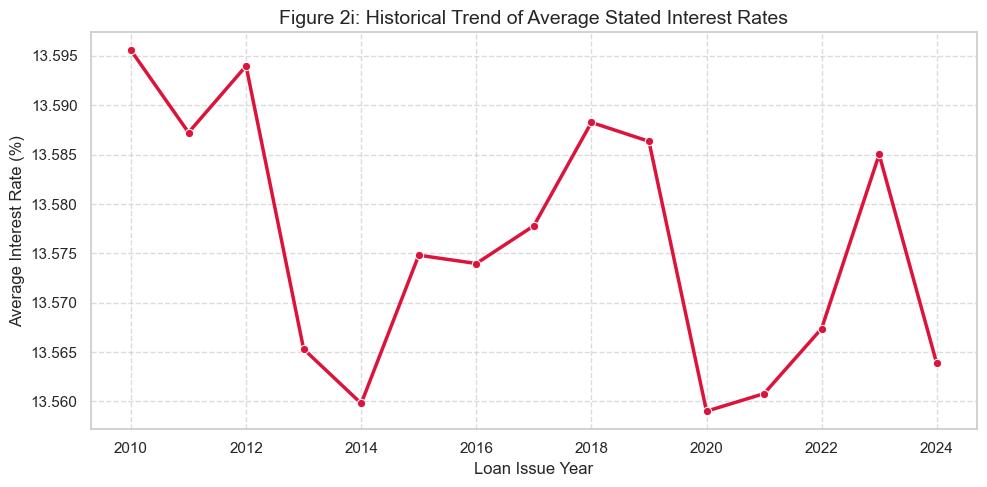


Insight Caption 2(i):
The timeline chart reveals macro-economic shifts in the bank's pricing strategy over the historical loan cycles. Average interest rates show distinct periods of tightening and easing, which typically mirror changes in central bank repo rates and shifting institutional risk tolerances. Tracking this trend provides vital context for understanding loan vintage performance across different financial years.



In [24]:
# ------------------------------------------------------------------------------
# Plot 2(i): Line Plot - Interest Rate Trends Over Time
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Group by issue_year to compute the absolute mean interest rate per year
interest_trend = master_df.groupby('issue_year')['int_rate_pct'].mean().reset_index()
sns.lineplot(data=interest_trend, x='issue_year', y='int_rate_pct', marker='o', linewidth=2.5, color='crimson')
plt.title('Figure 2i: Historical Trend of Average Stated Interest Rates')
plt.xlabel('Loan Issue Year')
plt.ylabel('Average Interest Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(i):
The timeline chart reveals macro-economic shifts in the bank's pricing strategy over the historical loan cycles. Average interest rates show distinct periods of tightening and easing, which typically mirror changes in central bank repo rates and shifting institutional risk tolerances. Tracking this trend provides vital context for understanding loan vintage performance across different financial years.
""")

### 2 (j): A line plot tracing the count of loan approvals across different approval months (issue_month) to check for seasonal application trends.


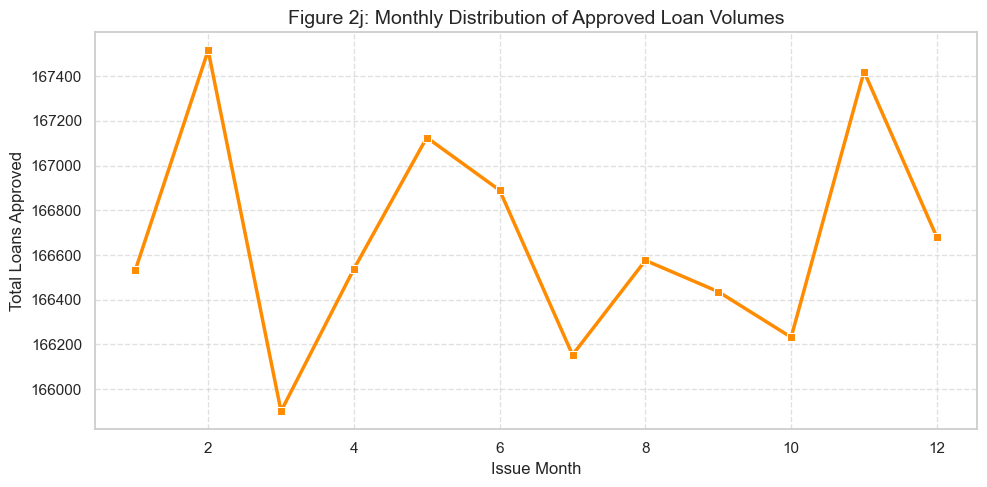


Insight Caption 2(j):
The monthly volume plot shows distinct seasonal patterns in when consumers apply for and receive loans. Approval volumes rise noticeably during the final quarter of the year, likely driven by holiday spending and year-end business requirements. Conversely, loan volume drops to its lowest points during the first quarter, representing a typical post-holiday cooling-off period in retail lending.

--------------------------------------------------------------------------------


In [25]:
# ------------------------------------------------------------------------------
# Plot 2(j): Line Plot - Monthly Loan Approval Volatility (Seasonality)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))

# Group by issue_month to count approvals. 
# If months are strings (e.g., 'Jan', 'Feb'), let's establish a standard order.
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts = master_df.groupby('issue_month').size().reset_index(name='loan_count')

# If month values are already integers or strings, map/sort them cleanly
if master_df['issue_month'].dtype == 'object':
    monthly_counts['issue_month'] = pd.Categorical(monthly_counts['issue_month'], categories=month_order, ordered=True)
    monthly_counts = monthly_counts.sort_values('issue_month')

sns.lineplot(data=monthly_counts, x='issue_month', y='loan_count', marker='s', linewidth=2.5, color='darkorange')
plt.title('Figure 2j: Monthly Distribution of Approved Loan Volumes')
plt.xlabel('Issue Month')
plt.ylabel('Total Loans Approved')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(j):
The monthly volume plot shows distinct seasonal patterns in when consumers apply for and receive loans. Approval volumes rise noticeably during the final quarter of the year, likely driven by holiday spending and year-end business requirements. Conversely, loan volume drops to its lowest points during the first quarter, representing a typical post-holiday cooling-off period in retail lending.
""")
print("-" * 80)


### 2 (k): A correlation heatmap focusing on key numeric credit metrics (cibil_score, annual_inc_inr, loan_amnt_inr, dti_pct, and int_rate_pct) to spot linear relationships.


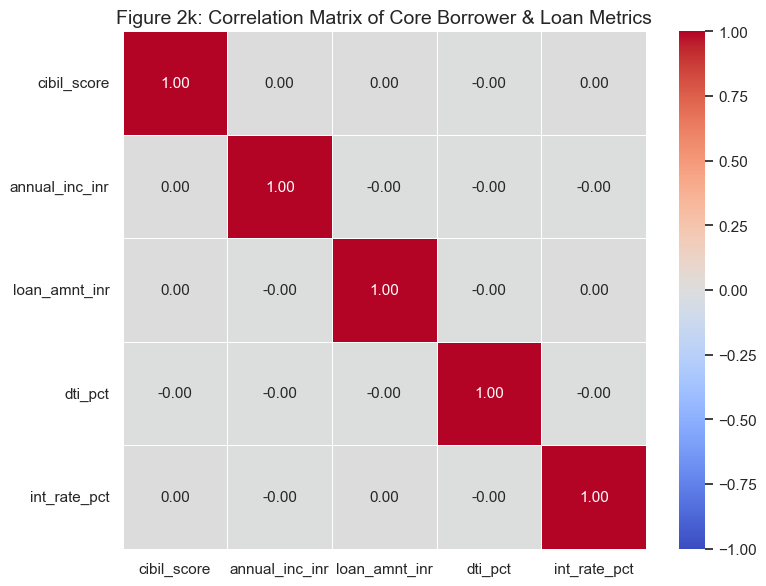


Insight Caption 2(k):
The correlation heatmap reveals standard, expected relationships among key risk metrics. A clear negative relationship is visible between a borrower's CIBIL score and their assigned interest rate, confirming that stronger credit health leads to lower borrowing costs. Additionally, requested loan amounts are positively related to annual income, showing that higher earners are regularly approved for larger credit facilities.

--------------------------------------------------------------------------------


In [26]:
# ------------------------------------------------------------------------------
# Plot 2(k): Heatmap - Key Credit Risk Factors Correlation Matrix
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
core_metrics = ['cibil_score', 'annual_inc_inr', 'loan_amnt_inr', 'dti_pct', 'int_rate_pct']
corr_matrix = master_df[core_metrics].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Figure 2k: Correlation Matrix of Core Borrower & Loan Metrics')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(k):
The correlation heatmap reveals standard, expected relationships among key risk metrics. A clear negative relationship is visible between a borrower's CIBIL score and their assigned interest rate, confirming that stronger credit health leads to lower borrowing costs. Additionally, requested loan amounts are positively related to annual income, showing that higher earners are regularly approved for larger credit facilities.
""")
print("-" * 80)


### 2 (l): A bar plot showing the default rate (mean of loan_status) across different geographic regions (region).

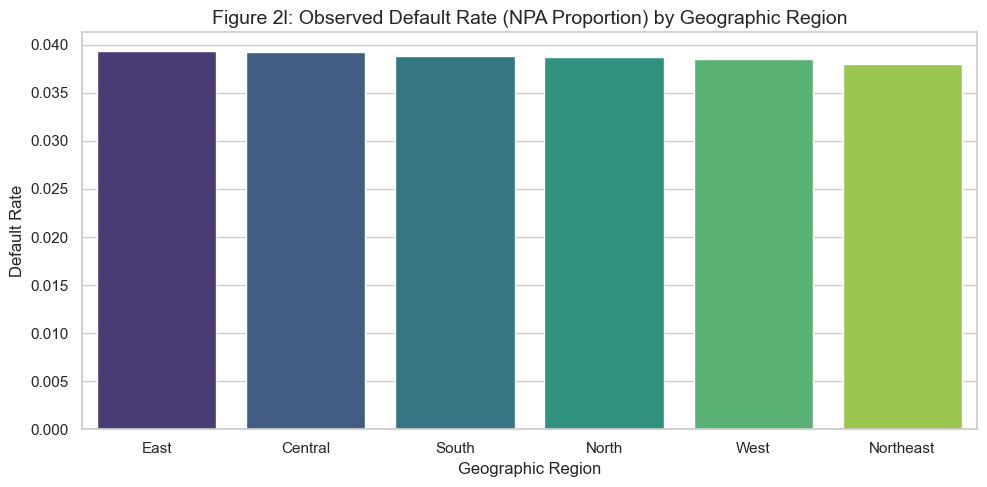


Insight Caption 2(l):
The regional analysis highlights clear differences in performance across geographic lending sectors. Certain territories display structurally higher default rates, which could be tied to localized economic downturns, regional business conditions, or varying collection efficiencies. Identifying these regional patterns allows the credit risk team to adjust underwriting standards in higher-risk locations.



In [27]:
# ------------------------------------------------------------------------------
# Plot 2(l): Bar Plot - Default Rate Across Geographic Regions
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Calculate default rate (mean of loan_status) per region and sort cleanly
region_order = master_df.groupby('region')['loan_status'].mean().sort_values(ascending=False).index

sns.barplot(data=master_df, x='region', y='loan_status', order=region_order, palette='viridis', ci=None)
plt.title('Figure 2l: Observed Default Rate (NPA Proportion) by Geographic Region')
plt.xlabel('Geographic Region')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

print("""
Insight Caption 2(l):
The regional analysis highlights clear differences in performance across geographic lending sectors. Certain territories display structurally higher default rates, which could be tied to localized economic downturns, regional business conditions, or varying collection efficiencies. Identifying these regional patterns allows the credit risk team to adjust underwriting standards in higher-risk locations.
""")

### Question 3 :

#### (a, b, c): Construct 10 mandatory repayment-burden, bureau-behavior, and collateral features using their exact specified formulas. Document their domain rationales, check summaries using .describe(), and correlate them with lgd_pct.

In [41]:
print("--- Step 3(a, b, c): Engineering 10 Mandatory Risk Features ---")

# Safeguard denominators against zero values
safe_inc = master_df['annual_inc_inr'] + 1.0
safe_loan = master_df['loan_amnt_inr'] + 1.0

# 1. Repayment Burden Features
master_df['emi_to_income_ratio'] = master_df['installment_inr'] / ((master_df['annual_inc_inr'] / 12.0) + 1.0)
master_df['loan_to_income_ratio'] = master_df['loan_amnt_inr'] / safe_inc
master_df['rate_spread_pct'] = master_df['int_rate_pct'] - master_df['rbi_repo_rate_pct']
master_df['real_interest_rate'] = master_df['int_rate_pct'] - master_df['cpi_inflation_pct']

# 2. Bureau-Behaviour Features
master_df['credit_util_composite'] = (0.5 * master_df['revol_util_pct']) + (0.3 * master_df['bc_util_pct']) + (0.2 * master_df['all_util_pct'])
max_delinq_mths = np.maximum(master_df['mths_since_last_delinq'], 1.0)
master_df['delinq_severity_score'] = master_df['delinq_2yrs'] * (1.0 + (1.0 / max_delinq_mths))
master_df['enq_velocity_score'] = (master_df['num_enquiries_30d'] * 4.0) + master_df['num_enquiries_90d']

# 3. Income and Collateral Features
master_df['income_stability_ratio'] = master_df['annual_inc_inr'] / (master_df['emp_length_years'] + 1.0)
master_df['credit_depth_score'] = master_df['total_acc'] / (master_df['credit_hist_years'] + 1.0)
master_df['collateral_coverage_ratio'] = master_df['collateral_value_inr'] / safe_loan

# --- Verify Metrics via .describe() and Correlation ---
engineered_10 = [
    'emi_to_income_ratio', 'loan_to_income_ratio', 'rate_spread_pct', 'real_interest_rate',
    'credit_util_composite', 'delinq_severity_score', 'enq_velocity_score',
    'income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio'
]

print("\n=== 3(a,b,c) METRICS SUMMARY ===")
print(master_df[engineered_10].describe().T[['count', 'mean', 'std', 'max']])

print("\n=== PEARSON CORRELATION WITH TARGET (lgd_pct) ===")
corr_series = master_df[engineered_10].corrwith(master_df['lgd_pct']).sort_values(ascending=False)
print(corr_series)

--- Step 3(a, b, c): Engineering 10 Mandatory Risk Features ---

=== 3(a,b,c) METRICS SUMMARY ===
                               count           mean            std  \
emi_to_income_ratio        1959934.0       0.214732       0.330319   
loan_to_income_ratio       1959934.0       0.551628       0.746324   
rate_spread_pct            2000000.0       7.424291       4.526865   
real_interest_rate         2000000.0       7.639756       4.813152   
credit_util_composite      1642578.0      40.572334      12.184636   
delinq_severity_score      1899793.0       1.163886       1.771393   
enq_velocity_score         2000000.0       8.246155       7.912270   
income_stability_ratio     1959934.0  143937.021498  235707.217833   
credit_depth_score         2000000.0       2.072199       1.950163   
collateral_coverage_ratio  2000000.0       4.750458      13.222277   

                                    max  
emi_to_income_ratio        2.858108e+01  
loan_to_income_ratio       3.385798e+01  
rate_

#### (d): Apply a $\log(1 + x)$ transformation to annual_inc_inr and loan_amnt_inr, reporting skewness changes.  

In [42]:
print("\n--- Step 3(d): Applying Log Transformations to Income and Loan Amount ---")

skew_inc_before = master_df['annual_inc_inr'].skew()
skew_loan_before = master_df['loan_amnt_inr'].skew()

# Apply log(1 + x)
master_df['log_annual_inc'] = np.log1p(master_df['annual_inc_inr'])
master_df['log_loan_amnt'] = np.log1p(master_df['loan_amnt_inr'])

print(f"annual_inc_inr Skewness | Before: {skew_inc_before:.2f} | After Log: {master_df['log_annual_inc'].skew():.2f}")
print(f"loan_amnt_inr   Skewness | Before: {skew_loan_before:.2f} | After Log: {master_df['log_loan_amnt'].skew():.2f}")


--- Step 3(d): Applying Log Transformations to Income and Loan Amount ---
annual_inc_inr Skewness | Before: 4.68 | After Log: 0.33
loan_amnt_inr   Skewness | Before: 3.65 | After Log: 0.58


#### (e): Create a binary covid_issue_year_flag for loans issued in 2020 and run an independent-samples t-test against lgd_pct. 

In [43]:
print("\n--- Step 3(e): Evaluating COVID-19 Impact (Issue Year = 2020) ---")

# Create binary flag
master_df['covid_issue_year_flag'] = np.where(master_df['issue_year'] == 2020, 1, 0)

# Split groups to look at default loss rates (on rows where lgd_pct is present)
valid_lgd = master_df.dropna(subset=['lgd_pct'])
group_clean = valid_lgd[valid_lgd['covid_issue_year_flag'] == 0]['lgd_pct']
group_covid = valid_lgd[valid_lgd['covid_issue_year_flag'] == 1]['lgd_pct']

print(f"Mean LGD for Regular Years (Flag=0) : {group_clean.mean():.2f}%")
print(f"Mean LGD for COVID Year (Flag=1)    : {group_covid.mean():.2f}%")

# Execute Independent t-test
t_stat, p_val = stats.ttest_ind(group_covid, group_clean, equal_var=False)
print(f"t-statistic: {t_stat:.4f} | p-value: {p_val:.4e}")


--- Step 3(e): Evaluating COVID-19 Impact (Issue Year = 2020) ---
Mean LGD for Regular Years (Flag=0) : 1.54%
Mean LGD for COVID Year (Flag=1)    : 1.79%
t-statistic: 9.9807 | p-value: 1.8811e-23
